#### [ MNIST 손글씨 숫자 이미지 분류 ]<hr>


- 데이터 : mnist_train.csv, mnist_test.csv
- 내_용 : 손글씨 그림을 저장한 파일. 0 ~ 9까지 숫자 데이터
- 주_제 : 숫자 0 ~ 9 이미지를 전달해서 정확하계 분류해주는 모델
- 학습 종류: 지도학습
- 학습 방법: KNN, SVC

- **[0] 모듈 로딩**

In [ ]:
## 데이터 분석 관련
import pandas as pd
import numpy as np

## 데이터 시각화 관련
import matplotlib.pyplot as plt
import koreanize_matplotlib

## ML 교차검증 관련
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

## ML 전처리 관련
from sklearn.preprocessing import MinMaxScaler

## ML 모델 관련
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

## ML 파이프라인 관련
from sklearn.pipeline import Pipeline

## ML 모델 저장
import joblib, os


- **[1] 데이터 준비 및 확인**

In [2]:
## 데이터 파일
TRAIN_FILE= './mnist_train.csv'
TEST_FILE= './mnist_test.csv'
MODEL_FILE= './Models/mnist_model.pkl'



In [3]:
## 데이터 로딩=> 첫번째 줄 컬럼x, 데이터 구분 쉼표(,)

trainDF= pd.read_csv(TRAIN_FILE, header=None)
testDF= pd.read_csv(TEST_FILE, header=None)

In [4]:
## 기본 정보 확인
trainDF.info()
print(trainDF.head(2), f'값: {trainDF.max()}, {trainDF.min()}\n', end= '\n\n')

testDF.info()
print(testDF.head(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 359.3 MB
   0    1    2    3    4    5    6    7    8    9    ...  775  776  777  778  \
0    5    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
1    0    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   

   779  780  781  782  783  784  
0    0    0    0    0    0    0  
1    0    0    0    0    0    0  

[2 rows x 785 columns] 값: 0       9
1       0
2       0
3       0
4       0
       ..
780    62
781     0
782     0
783     0
784     0
Length: 785, dtype: int64, 0      0
1      0
2      0
3      0
4      0
      ..
780    0
781    0
782    0
783    0
784    0
Length: 785, dtype: int64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 59.9 MB
   0    1    2    3    4    5    6    7    8    9    ...  775  776  77

In [5]:
## ------------------------------------------------
## [해석]
## - 이미지 픽셀 값으로 0~ 255
## - 모든 컬럼이 숫자값
## - 타겟 컬럼은 0번 컬럼
## ------------------------------------------------

- **[2] 힉습용| 테스트용 데이터 준비**

In [6]:
## 학습용/ 테스트용 데이터 파일 분리
## 피쳐와 타겟 분리

X_train= trainDF[trainDF.columns[1:]]
y_train= trainDF[trainDF.columns[0]]

X_test = testDF[ testDF. columns [1: ] ]
y_test = testDF[ testDF. columns[0 ] ]

print(f'[Train] {X_train.shape}, {y_train.shape}')
print(f'[Test] {X_test.shape}, {y_test.shape}')

[Train] (60000, 784), (60000,)
[Test] (10000, 784), (10000,)


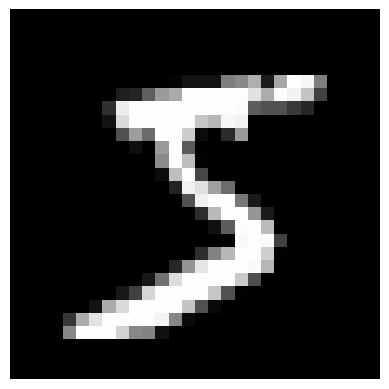

In [7]:
plt.imshow(X_train.iloc[0].to_numpy().reshape(28, 28), cmap='gray')
plt.axis('off')
plt.show()

- **[3] 데이터 분석 및 전처리**
    - 클래스 균형/ 불균형 체크
    - 피쳐 전처리 방법 결정

In [8]:
## 클래스 균형- 불균형 체크
print(f'[Train Class]\n{y_train.value_counts().to_list()}')
print(f'{(y_train.value_counts(normalize=True)).round(2).to_list()}')

## => 클래스병 데이터 수 균형!!!
# -> 0~ 9까지 숫자가 균형있게 있어야 하는데 없으면 안 됨

[Train Class]
[6742, 6265, 6131, 5958, 5949, 5923, 5918, 5851, 5842, 5421]
[0.11, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.09]


In [9]:
## => 1개 행만 추출 피쳐 확인
X_train.iloc[0].describe()


count    784.000000
mean      35.108418
std       79.699674
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      255.000000
Name: 0, dtype: float64

- **[4] 전처리+ 교차검증+ 튜닝**

In [10]:
## 전처리 인스턴스
## 모델 파라미터 Dict
## 모델 인스턴스
## 교차검증 인스턴스
## 튜닝 인스턴스
## 파이프라인 인스턴스


In [11]:
## 전처리 인스턴스

scaler= MinMaxScaler()


## 모델 파라미터 Dict
params = {
    'model__n_neighbors': range(3, 51, 2),
    'model__weights': ['uniform', 'distance'],
    'model__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

## 모델 인스턴스
model = KNeighborsClassifier()


In [12]:
## 교차검증 인스턴스 ===> Strat 어쩌구

## 교차검증 인스턴스
skfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=10
)

In [13]:
## 파이프라인 인스턴스
pipe = Pipeline([
    ('scaler', scaler),
    ('model', model)
])


## 튜닝 인스턴스
grid_model = GridSearchCV(
    estimator=pipe,
    param_grid=params,
    scoring='accuracy',
    cv=skfold,
    n_jobs=1,          # WinError 1450 방지
    pre_dispatch=1,
    verbose=2
)





In [ ]:
## 전체 데이터 학습
grid_model.fit(X_train, y_train)


Fitting 5 folds for each of 192 candidates, totalling 960 fits


c:\Users\KDT30\anaconda3\envs\hanicv\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


[CV] END model__algorithm=auto, model__n_neighbors=3, model__weights=uniform; total time=   7.6s
[CV] END model__algorithm=auto, model__n_neighbors=3, model__weights=uniform; total time=   4.5s
[CV] END model__algorithm=auto, model__n_neighbors=3, model__weights=uniform; total time=   4.5s
[CV] END model__algorithm=auto, model__n_neighbors=3, model__weights=uniform; total time=   4.5s
[CV] END model__algorithm=auto, model__n_neighbors=3, model__weights=uniform; total time=   4.6s
[CV] END model__algorithm=auto, model__n_neighbors=3, model__weights=distance; total time=   4.3s
[CV] END model__algorithm=auto, model__n_neighbors=3, model__weights=distance; total time=   4.2s
[CV] END model__algorithm=auto, model__n_neighbors=3, model__weights=distance; total time=   4.2s
[CV] END model__algorithm=auto, model__n_neighbors=3, model__weights=distance; total time=   4.2s
[CV] END model__algorithm=auto, model__n_neighbors=3, model__weights=distance; total time=   4.1s
[CV] END model__algorithm

- **[5] 성능평가**

In [ ]:


print('최적 파라미터:', grid_model.best_params_)
print('교차검증 최고 점수:', grid_model.best_score_)
print('테스트 점수:', grid_model.score(X_test, y_test))


- **[6] 모델 저장**